In [1]:
%matplotlib notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
df = pd.read_csv(r'./sir.csv', header=None)
raw = df.values

In [3]:
S = []
I = []
R = []
for i in range(2,len(raw),5):
    S.append(float(raw[i][0]))
    I.append(float(raw[i+1][0]))
    R.append(float(raw[i+2][0]))
t = []
for i in range(len(S)):
    t.append(0.05 * i)

In [4]:
def update(frame, S_curve, I_curve, R_curve, ax):
    S_curve.set_data(t[:frame], S[:frame])
    I_curve.set_data(t[:frame], I[:frame])
    R_curve.set_data(t[:frame], R[:frame])
    ax.set_xlim(0, 0.05 * frame)
    return S_curve, I_curve, R_curve

<IPython.core.display.Javascript object>


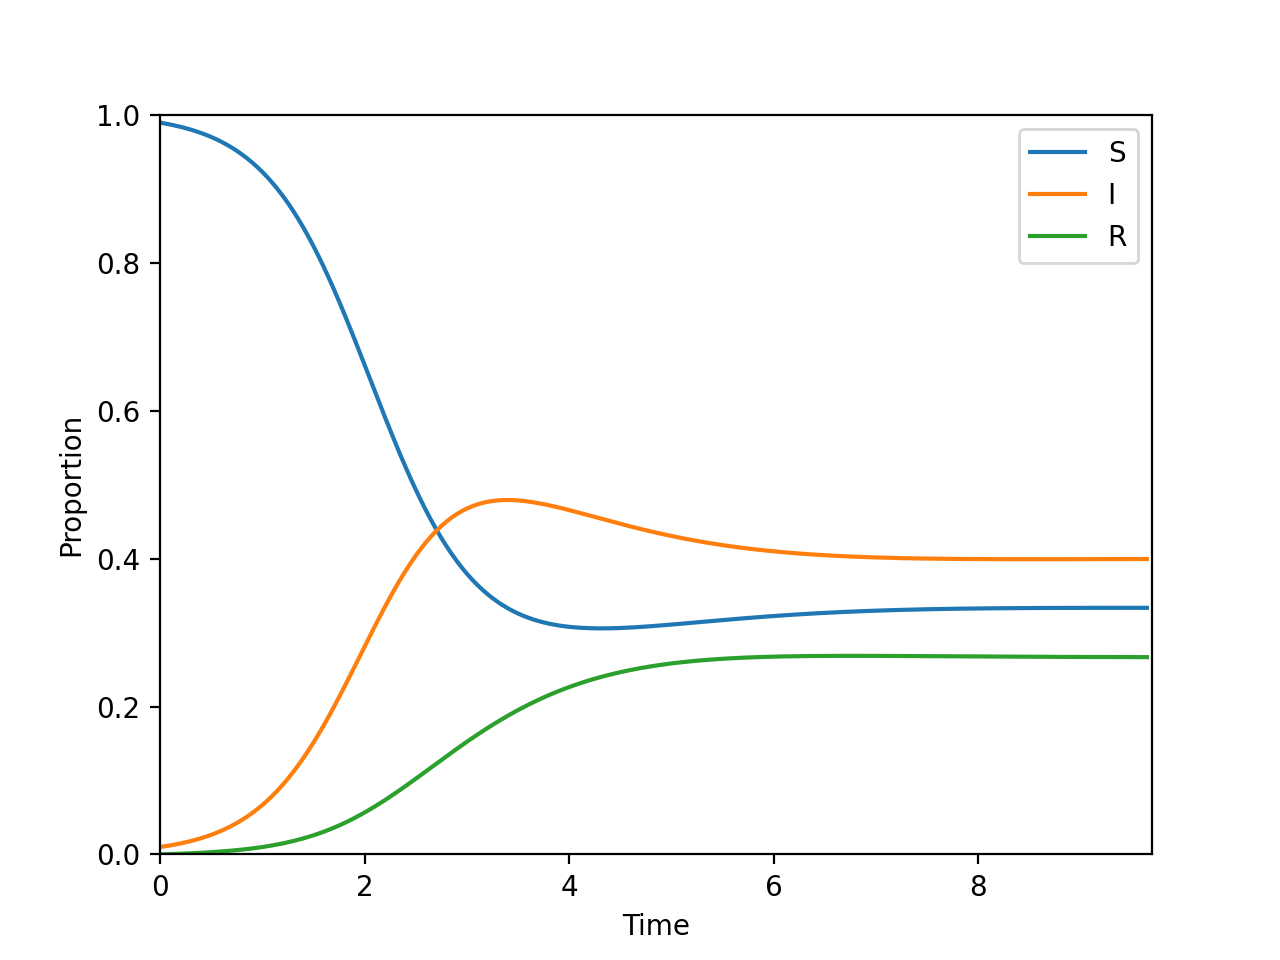

In [5]:
fig, ax = plt.subplots()
S_curve = ax.plot([], [], label="S")[0]
I_curve = ax.plot([], [], label="I")[0]
R_curve = ax.plot([], [], label="R")[0]

ax.set(xlabel="Time")
ax.set(ylabel="Proportion")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

ani = animation.FuncAnimation(
    fig, update, frames=len(S), fargs=(S_curve, I_curve, R_curve, ax), interval=50, repeat_delay=5000)
plt.show()